# Dollar Spot Prediction 


In [1]:
import pandas as pd
import numpy as np
import xlrd
import warnings
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


##  Configuration

In [8]:

DATA_PATH = r"2008+to+2010+5+day+MoveAve+datasets.xls"


RANDOM_SEED = 42
THRESHOLD   = 0.20    # Smith-Kerns 20% action threshold

# Feature sets 
FS1 = ['meanRH', 'meanAT', 'Fungicide']

FS2 = ['meanRH', 'meanAT', 'Fungicide',
       'meanLW', 'minAT', 'maxRH', 'minST']

FS3 = ['meanRH', 'meanAT', 'Fungicide',
       'meanLW', 'minAT', 'maxRH', 'minST',
       'maxAT', 'minRH', 'meanSM', 'meanRF']

FEATURE_SETS = {'FS1': FS1, 'FS2': FS2, 'FS3': FS3}

# Columns eligible for normalisation 
CONTINUOUS_COLS = ['meanRH', 'meanAT', 'meanLW', 'minAT', 'maxRH', 'minST',
                   'maxAT', 'minRH', 'meanSM', 'meanRF', 'meanST']

print('Config OK')
print(f'FS1: {FS1}')
print(f'FS2: {FS2}')
print(f'FS3: {FS3}')

Config OK
FS1: ['meanRH', 'meanAT', 'Fungicide']
FS2: ['meanRH', 'meanAT', 'Fungicide', 'meanLW', 'minAT', 'maxRH', 'minST']
FS3: ['meanRH', 'meanAT', 'Fungicide', 'meanLW', 'minAT', 'maxRH', 'minST', 'maxAT', 'minRH', 'meanSM', 'meanRF']


In [9]:
def load_data(filepath):
    wb = xlrd.open_workbook(filepath)
    ws = wb.sheet_by_name('Total 5-day Dataset')

    headers = ws.row_values(0)
    data    = [ws.row_values(i) for i in range(1, ws.nrows)]
    df      = pd.DataFrame(data, columns=headers)
    #remove rows with no site or year
    df = df[df['Site'].astype(str).str.strip() != ''].copy()
    df = df[df['Year'] != ''].copy()
    #convert excel date into date and add nat for non date values
    df['Date'] = df['Date'].apply(
        lambda x: xlrd.xldate_as_datetime(x, wb.datemode)
        if isinstance(x, float) else pd.NaT
    )
    #each weather column has been converted to a proper number, as in excel they come as mixed types or strings
    numeric_cols = ['Year', 'Rep', 'Fungicide', 'Foci',
                    'meanRH', 'meanAT', 'meanLW', 'meanST', 'meanSM', 'meanRF',
                    'maxRH', 'maxAT', 'minRH', 'minAT', 'minST']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    #years are converted to int
    df['Year'] = df['Year'].astype(int)
    return df


df_raw = load_data(DATA_PATH)

print(f'Raw rows loaded : {len(df_raw):,}')
print(f'Sites           : {sorted(df_raw["Site"].unique())}')
print(f'Years           : {sorted(df_raw["Year"].unique())}')
df_raw.head(3)

Raw rows loaded : 7,182
Sites           : ['Noer', 'STILL', 'UR14', 'UR7']
Years           : [2008, 2009, 2010]


,State,Site,Rating,Date,Year,Season,Obs,Rep,Treatment,Fungicide,...,maxLW,maxST,maxSM,maxRH,maxAT,maxRF,minST,minSM,minRH,minAT
0,OK,STILL,1.0,2008-04-24,2008,Spring,101.0,1.0,PREV,1.0,...,8.02,22.38,33.6,92.54,28.2,0.52,16.36,28.7,42.74,15.38
1,OK,STILL,1.0,2008-04-24,2008,Spring,102.0,1.0,CUR,1.0,...,8.02,22.38,33.6,92.54,28.2,0.52,16.36,28.7,42.74,15.38
2,OK,STILL,1.0,2008-04-24,2008,Spring,103.0,1.0,CHECK,0.0,...,8.02,22.38,33.6,92.54,28.2,0.52,16.36,28.7,42.74,15.38


## Preprocess 

In [10]:
# Before aggregation
print(f'Raw rows (replicate level): {len(df_raw):,}')
print(f'Each site-date has multiple rows — one per replicate plot')
print()
print('Sample of raw data (same date, multiple reps):')
display(df_raw[df_raw['Date'] == df_raw['Date'].iloc[0]][
    ['Site', 'Date', 'Rep', 'Treatment', 'Foci', 'Fungicide', 'meanRH', 'meanAT']
].head(6))

Raw rows (replicate level): 7,182
Each site-date has multiple rows — one per replicate plot

Sample of raw data (same date, multiple reps):


,Site,Date,Rep,Treatment,Foci,Fungicide,meanRH,meanAT
0,STILL,2008-04-24,1.0,PREV,2.0,1.0,71.1967,21.2725
1,STILL,2008-04-24,1.0,CUR,0.0,1.0,71.1967,21.2725
2,STILL,2008-04-24,1.0,CHECK,0.0,0.0,71.1967,21.2725
3,STILL,2008-04-24,2.0,CUR,0.0,1.0,71.1967,21.2725
4,STILL,2008-04-24,2.0,PREV,0.0,1.0,71.1967,21.2725
5,STILL,2008-04-24,2.0,CHECK,9.0,0.0,71.1967,21.2725


In [11]:
weather_cols = ['meanRH', 'meanAT', 'meanLW', 'meanST', 'meanSM', 'meanRF',
                'maxRH', 'maxAT', 'minRH', 'minAT', 'minST']

agg_dict = {col: 'first' for col in weather_cols if col in df_raw.columns}
agg_dict['Foci']      = 'mean'
agg_dict['Fungicide'] = 'max'
agg_dict['Year']      = 'first'
if 'State' in df_raw.columns:
    agg_dict['State'] = 'first'

daily = df_raw.groupby(['Site', 'Date', 'Treatment']).agg(agg_dict).reset_index()

# After aggregation
print(f'Rows before aggregation : {len(df_raw):,}')
print(f'Rows after aggregation  : {len(daily):,}')
print(f'Reduction               : {len(df_raw) - len(daily):,} replicate rows collapsed')
print()
print('Same date now has one row per site:')
display(daily[daily['Date'] == daily['Date'].iloc[0]][
    ['Site', 'Date', 'Treatment', 'Foci', 'Fungicide', 'meanRH', 'meanAT']
].head(10))

Rows before aggregation : 7,182
Rows after aggregation  : 1,197
Reduction               : 5,985 replicate rows collapsed

Same date now has one row per site:


,Site,Date,Treatment,Foci,Fungicide,meanRH,meanAT
0,Noer,2010-06-02,CHECK,0.000000,0.0,69.5902,21.3412
1,Noer,2010-06-02,CUR,0.000000,0.0,69.5902,21.3412
2,Noer,2010-06-02,PREV,0.000000,1.0,69.5902,21.3412
669,UR14,2010-06-02,CHECK,0.333333,0.0,66.3058,21.9856
670,UR14,2010-06-02,CUR,0.500000,0.0,66.3058,21.9856
671,UR14,2010-06-02,PREV,0.166667,1.0,66.3058,21.9856
933,UR7,2010-06-02,CHECK,1.333333,0.0,68.0171,21.6502
934,UR7,2010-06-02,CUR,1.500000,0.0,68.0171,21.6502
935,UR7,2010-06-02,PREV,1.666667,1.0,68.0171,21.6502


In [12]:
daily['disease_event'] = (daily['Foci'] > 0).astype(int)

print('Target variable created: disease_event')
print()
print(f'Disease present (1) : {daily["disease_event"].sum():,}  ({daily["disease_event"].mean():.1%})')
print(f'Healthy     (0)     : {(daily["disease_event"]==0).sum():,}  ({(1 - daily["disease_event"].mean()):.1%})')
print()
print('Class balance is near 50/50 — no resampling needed')
print()

# what the conversion looks like
print('Foci count → disease_event:')
display(daily[['Site', 'Date', 'Foci', 'disease_event']].sample(8, random_state=42))

Target variable created: disease_event

Disease present (1) : 590  (49.3%)
Healthy     (0)     : 607  (50.7%)

Class balance is near 50/50 — no resampling needed

Foci count → disease_event:


,Site,Date,Foci,disease_event
921,UR14,2125-08-16,0.000000,0
321,STILL,2008-05-13,0.000000,0
101,Noer,2072-03-26,0.000000,0
920,UR14,2125-01-28,0.000000,0
58,Noer,2010-08-06,15.500000,1
790,UR14,2093-04-25,0.000000,0
948,UR7,2010-06-15,6.666667,1
969,UR7,2010-07-02,0.000000,0


In [13]:
# site-year labels for GroupKFold
daily['site_year'] = daily['Site'] + '_' + daily['Year'].astype(str)

print('Site-year groups (used for cross-validation folds):')
for sy, count in daily.groupby('site_year').size().items():
    print(f'  {sy:<15} {count:>4} observations')

print()

# drop missing primary features
before = len(daily)
daily  = daily.dropna(subset=['meanRH', 'meanAT', 'disease_event']).copy()
print(f'Rows dropped (missing primary features): {before - len(daily)}')


secondary = ['meanLW', 'minAT', 'maxRH', 'minST',
             'maxAT', 'minRH', 'meanSM', 'meanRF', 'meanST']
for col in secondary:
    if col in daily.columns:
        daily[col] = (
            daily.groupby('site_year')[col]
                 .transform(lambda x: x.fillna(method='ffill').fillna(x.median()))
        )

print(f'Missing values in secondary features after fill:')
print(daily[secondary].isnull().sum())

Site-year groups (used for cross-validation folds):
  Noer_2009        195 observations
  Noer_2010         69 observations
  STILL_2008       279 observations
  STILL_2009       126 observations
  UR14_2009        195 observations
  UR14_2010         69 observations
  UR7_2009         195 observations
  UR7_2010          69 observations

Rows dropped (missing primary features): 15
Missing values in secondary features after fill:
meanLW    0
minAT     0
maxRH     0
minST     0
maxAT     0
minRH     0
meanSM    0
meanRF    0
meanST    0
dtype: int64


In [14]:
df = daily.copy()


print(f'Final observations  : {len(df):,}')
print(f'Disease event rate  : {df["disease_event"].mean():.1%}')
print(f'Disease present     : {df["disease_event"].sum():,}')
print(f'Healthy             : {(df["disease_event"]==0).sum():,}')
print(f'Site-years          : {df["site_year"].nunique()}')
print()
print('Columns available for modelling:')
print([c for c in df.columns if c in weather_cols + ['Fungicide', 'disease_event', 'site_year']])
print()
display(df[['Site', 'Date', 'site_year', 'meanRH', 'meanAT', 
            'Fungicide', 'Foci', 'disease_event']].head(5))

Final observations  : 1,182
Disease event rate  : 48.6%
Disease present     : 575
Healthy             : 607
Site-years          : 8

Columns available for modelling:
['meanRH', 'meanAT', 'meanLW', 'meanST', 'meanSM', 'meanRF', 'maxRH', 'maxAT', 'minRH', 'minAT', 'minST', 'Fungicide', 'disease_event', 'site_year']



,Site,Date,site_year,meanRH,meanAT,Fungicide,Foci,disease_event
0,Noer,2010-06-02,Noer_2010,69.5902,21.3412,0.0,0.0,0
1,Noer,2010-06-02,Noer_2010,69.5902,21.3412,0.0,0.0,0
2,Noer,2010-06-02,Noer_2010,69.5902,21.3412,1.0,0.0,0
3,Noer,2010-06-03,Noer_2010,72.8589,20.3037,0.0,0.0,0
4,Noer,2010-06-03,Noer_2010,72.8589,20.3037,0.0,0.0,0


## Normalisation Functions (NS1 and NS2)

In [15]:
def apply_ns1(X_train, X_test, feature_cols):
    """
    NS1: Global StandardScaler.
    """
    cont = [c for c in feature_cols if c in CONTINUOUS_COLS]
    Xtr  = X_train.copy()
    Xte  = X_test.copy()
    if cont:
        scaler = StandardScaler()
        Xtr[cont] = scaler.fit_transform(X_train[cont])
        Xte[cont] = scaler.transform(X_test[cont])
    return Xtr, Xte


def apply_ns2(X_train, X_test, groups_train, groups_test, feature_cols):
    """
    NS2: Site-specific normalisation.
    """
    cont = [c for c in feature_cols if c in CONTINUOUS_COLS]
    Xtr  = X_train.copy()
    Xte  = X_test.copy()

    if not cont:
        return Xtr, Xte

    # Extract site names 
    train_sites = pd.Series(groups_train).str.rsplit('_', n=1).str[0].values
    test_sites  = pd.Series(groups_test).str.rsplit('_', n=1).str[0].values

    # per-site stats from training fold
    site_stats = {}
    for site in np.unique(train_sites):
        mask = train_sites == site
        idx  = X_train.index[mask]
        site_stats[site] = {
            col: {'mean': X_train.loc[idx, col].mean(),
                  'std':  max(X_train.loc[idx, col].std(), 1e-8)}
            for col in cont
        }

    
    global_stats = {
        col: {'mean': X_train[col].mean(),
              'std':  max(X_train[col].std(), 1e-8)}
        for col in cont
    }

    # training rows
    for i, site in enumerate(train_sites):
        stats = site_stats.get(site, global_stats)
        idx   = X_train.index[i]
        for col in cont:
            Xtr.at[idx, col] = (X_train.at[idx, col] - stats[col]['mean']) / stats[col]['std']

    # test rows 
    for i, site in enumerate(test_sites):
        stats = site_stats.get(site, global_stats)
        idx   = X_test.index[i]
        for col in cont:
            Xte.at[idx, col] = (X_test.at[idx, col] - stats[col]['mean']) / stats[col]['std']

    return Xtr, Xte


print('Normalisation functions defined: apply_ns1(), apply_ns2()')

Normalisation functions defined: apply_ns1(), apply_ns2()


## Model Definitions

In [16]:
def get_model(name):
    
    if name == 'LR':
        # No regularisation 
        return LogisticRegression(
            penalty=None,
            solver='lbfgs',
            max_iter=1000,
            random_state=RANDOM_SEED
        )

    elif name == 'RF':
        # 500 trees
        return RandomForestClassifier(
            n_estimators=500,
            max_features='sqrt',
            min_samples_split=2,
            n_jobs=-1,
            random_state=RANDOM_SEED
        )

    elif name == 'XGB':
        
        return XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=RANDOM_SEED,
            eval_metric='logloss',
            verbosity=0
        )

    raise ValueError(f'Unknown model: {name}')


print('Models defined')

Models defined


## Core CV Function 

In [17]:
# Show the 8 folds before running anything
# This makes the CV design visible before the model runs

sy_list = sorted(df['site_year'].unique())
gkf     = GroupKFold(n_splits=len(sy_list))

X_dummy = df[FS1].copy()
y_dummy = df['disease_event'].values
groups  = df['site_year'].values

print('GroupKFold cross-validation: 8 folds, one per site-year')
print('In each fold: 7 site-years train, 1 site-year tests')
print()
print(f'{"Fold":<6} {"Test Site-Year":<15} {"Train rows":>12} {"Test rows":>10}')


for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X_dummy, y_dummy, groups), 1):
    test_sy   = np.unique(groups[test_idx])[0]
    print(f'{fold_idx:<6} {test_sy:<15} {len(train_idx):>12,} {len(test_idx):>10,}')

GroupKFold cross-validation: 8 folds, one per site-year
In each fold: 7 site-years train, 1 site-year tests

Fold   Test Site-Year    Train rows  Test rows
1      STILL_2008               903        279
2      UR7_2009                 987        195
3      UR14_2009                987        195
4      Noer_2009                990        192
5      STILL_2009             1,056        126
6      UR7_2010               1,113         69
7      Noer_2010              1,113         69
8      UR14_2010              1,125         57


In [19]:
# fold 1 to demonstrate NS1 vs NS2 visually

train_idx, test_idx = list(gkf.split(X_dummy, y_dummy, groups))[0]

X_train_raw = df[FS2].iloc[train_idx].copy()
X_test_raw  = df[FS2].iloc[test_idx].copy()
g_train     = groups[train_idx]
g_test      = groups[test_idx]

X_train_ns1, X_test_ns1 = apply_ns1(X_train_raw, X_test_raw, FS2)
X_train_ns2, X_test_ns2 = apply_ns2(X_train_raw, X_test_raw, g_train, g_test, FS2)

print('Effect of normalisation on meanRH (first fold, test rows)')
print()
comparison = pd.DataFrame({
    'Raw value':        X_test_raw['meanRH'].values[:8].round(2),
    'NS1 (global)':     X_test_ns1['meanRH'].values[:8].round(3),
    'NS2 (site-spec)':  X_test_ns2['meanRH'].values[:8].round(3),
})
print(comparison.to_string(index=False))
print()
print('NS1: scaled relative to the global training average')
print('NS2: scaled relative to that specific site\'s average')


Effect of normalisation on meanRH (first fold, test rows)

 Raw value  NS1 (global)  NS2 (site-spec)
     71.20        -0.801           -0.039
     71.20        -0.801           -0.039
     71.20        -0.801           -0.039
     75.75        -0.160            0.380
     75.75        -0.160            0.380
     75.75        -0.160            0.380
     75.15        -0.245            0.325
     75.15        -0.245            0.325

NS1: scaled relative to the global training average
NS2: scaled relative to that specific site's average


In [20]:


feature_cols = FS1   # start with baseline features
model_name   = 'LR'
norm         = 'NS1'

# split
train_idx, test_idx = list(gkf.split(df[feature_cols], y_dummy, groups))[0]
X_train = df[feature_cols].iloc[train_idx].copy()
X_test  = df[feature_cols].iloc[test_idx].copy()
y_train = df['disease_event'].values[train_idx]
y_test  = df['disease_event'].values[test_idx]
g_train = groups[train_idx]
g_test  = groups[test_idx]
test_sy = np.unique(g_test)[0]

print(f'Step 1 — Split')
print(f'  Test fold    : {test_sy}')
print(f'  Train rows   : {len(X_train):,}')
print(f'  Test rows    : {len(X_test):,}')
print()

#  normalise
X_train_n, X_test_n = apply_ns1(X_train, X_test, feature_cols)
print(f'Step 2 — Normalise (NS1)')
print(f'  meanRH before : mean={X_train["meanRH"].mean():.1f}  std={X_train["meanRH"].std():.1f}')
print(f'  meanRH after  : mean={X_train_n["meanRH"].mean():.3f}  std={X_train_n["meanRH"].std():.3f}')
print()

# train
model = get_model(model_name)
model.fit(X_train_n.values, y_train)
print(f'Step 3 — Train {model_name}')
print(f'  Coefficients : {dict(zip(feature_cols, model.coef_[0].round(3)))}')
print()

# predict
y_proba = model.predict_proba(X_test_n.values)[:, 1]
auc     = roc_auc_score(y_test, y_proba)
print(f'Step 4 — Predict on test fold')
print(f'  Sample probabilities : {y_proba[:5].round(3)}')
print(f'  Actual labels        : {y_test[:5]}')
print()
print(f'  AUC-ROC for fold [{test_sy}] : {auc:.3f}')

Step 1 — Split
  Test fold    : STILL_2008
  Train rows   : 903
  Test rows    : 279

Step 2 — Normalise (NS1)
  meanRH before : mean=76.9  std=7.1
  meanRH after  : mean=-0.000  std=1.001

Step 3 — Train LR
  Coefficients : {'meanRH': 0.41, 'meanAT': 0.584, 'Fungicide': -0.624}

Step 4 — Predict on test fold
  Sample probabilities : [0.548 0.394 0.394 0.599 0.445]
  Actual labels        : [1 1 1 1 1]

  AUC-ROC for fold [STILL_2008] : 0.721


In [22]:

# repeats those steps across all 8 folds automatically

def run_condition(df, model_name, fs_name, norm, verbose=True):
    
    feature_cols = [f for f in FEATURE_SETS[fs_name] if f in df.columns]
    X      = df[feature_cols].copy()
    y      = df['disease_event'].values
    groups = df['site_year'].values
    sy_list = sorted(df['site_year'].unique())
    gkf    = GroupKFold(n_splits=len(sy_list))

    fold_results = {}
    all_y_true   = []
    all_y_proba  = []

    for train_idx, test_idx in gkf.split(X, y, groups):
        X_train = X.iloc[train_idx].copy()
        X_test  = X.iloc[test_idx].copy()
        y_train = y[train_idx]
        y_test  = y[test_idx]
        g_train = groups[train_idx]
        g_test  = groups[test_idx]

        
        if norm == 'NS1':
            X_train_n, X_test_n = apply_ns1(X_train, X_test, feature_cols)
        else:
            X_train_n, X_test_n = apply_ns2(X_train, X_test, g_train, g_test, feature_cols)

        
        model   = get_model(model_name)
        model.fit(X_train_n.values, y_train)
        y_proba = model.predict_proba(X_test_n.values)[:, 1]

        
        sy_test  = np.unique(g_test)[0]
        fold_auc = roc_auc_score(y_test, y_proba)
        fold_results[sy_test] = fold_auc

        if verbose:
            print(f'  Fold [{sy_test:<12}]  AUC = {fold_auc:.3f}')

        all_y_true.extend(y_test)
        all_y_proba.extend(y_proba)

    
    all_y_true  = np.array(all_y_true)
    all_y_proba = np.array(all_y_proba)
    overall_auc = roc_auc_score(all_y_true, all_y_proba)
    fold_aucs   = [fold_results[sy] for sy in sy_list]
    mean_auc    = float(np.mean(fold_aucs))
    std_auc     = float(np.std(fold_aucs))

    y_pred = (all_y_proba >= THRESHOLD).astype(int)
    tn, fp, fn, tp = confusion_matrix(all_y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    if verbose:
        print(f'\n  Mean AUC    : {mean_auc:.3f} ± {std_auc:.3f}')
        print(f'  Overall AUC : {overall_auc:.3f}')
        print(f'  Sens@20%    : {sensitivity:.3f}')
        print(f'  Spec@20%    : {specificity:.3f}')

    return {
        'Model':        model_name,
        'Feature Set':  fs_name,
        'Norm':         norm,
        'Mean AUC':     round(mean_auc, 3),
        'SD':           round(std_auc, 3),
        'Overall AUC':  round(overall_auc, 3),
        'Sens@20%':     round(sensitivity, 3),
        'Spec@20%':     round(specificity, 3),
        'fold_results': fold_results,
        'y_true':       all_y_true,
        'y_proba':      all_y_proba,
        'feature_cols': feature_cols,
    }



## Run Logistic Regression 

In [23]:
# RO1: Replicate the Smith-Kerns baseline

print('RO1 : Smith-Kerns Baseline Replication')
print('Features : meanRH, meanAT, Fungicide  ')
print('Model    : Logistic Regression, no regularisation')
print('Norm     : NS1 ')
print()

lr_baseline = run_condition(df, 'LR', 'FS1', 'NS1')

print()
print(f'Smith-Kerns published AUC : 0.770')
print(f'This study baseline AUC   : {lr_baseline["Overall AUC"]:.3f}')

RO1 : Smith-Kerns Baseline Replication
Features : meanRH, meanAT, Fungicide  
Model    : Logistic Regression, no regularisation
Norm     : NS1 

  Fold [STILL_2008  ]  AUC = 0.721
  Fold [UR7_2009    ]  AUC = 0.763
  Fold [UR14_2009   ]  AUC = 0.619
  Fold [Noer_2009   ]  AUC = 0.686
  Fold [STILL_2009  ]  AUC = 0.944
  Fold [UR7_2010    ]  AUC = 0.744
  Fold [Noer_2010   ]  AUC = 0.675
  Fold [UR14_2010   ]  AUC = 0.651

  Mean AUC    : 0.725 ± 0.094
  Overall AUC : 0.650
  Sens@20%    : 0.963
  Spec@20%    : 0.125

Smith-Kerns published AUC : 0.770
This study baseline AUC   : 0.650


In [24]:
# RO4: Does site-specific normalisation improve cross-regional performance?
# Same features as baseline, only the normalisation changes

print('RO4 : Site-Specific Normalisation (FS1)')
print('Features : same as baseline (FS1)')
print('Norm     : NS2 ')
print()

lr_baseline_ns2 = run_condition(df, 'LR', 'FS1', 'NS2')

print()
print('Comparison on FS1:')
print(f'  NS1 Mean AUC : {lr_baseline["Mean AUC"]:.3f}')
print(f'  NS2 Mean AUC : {lr_baseline_ns2["Mean AUC"]:.3f}')
print(f'  Difference   : {lr_baseline_ns2["Mean AUC"] - lr_baseline["Mean AUC"]:+.3f}')

RO4 : Site-Specific Normalisation (FS1)
Features : same as baseline (FS1)
Norm     : NS2 

  Fold [STILL_2008  ]  AUC = 0.779
  Fold [UR7_2009    ]  AUC = 0.753
  Fold [UR14_2009   ]  AUC = 0.650
  Fold [Noer_2009   ]  AUC = 0.689
  Fold [STILL_2009  ]  AUC = 0.940
  Fold [UR7_2010    ]  AUC = 0.708
  Fold [Noer_2010   ]  AUC = 0.662
  Fold [UR14_2010   ]  AUC = 0.616

  Mean AUC    : 0.725 ± 0.095
  Overall AUC : 0.700
  Sens@20%    : 0.903
  Spec@20%    : 0.175

Comparison on FS1:
  NS1 Mean AUC : 0.725
  NS2 Mean AUC : 0.725
  Difference   : +0.000


In [25]:
# RO2: Do additional weather variables improve on the baseline?
# Adding leaf wetness, min temperature, max RH, min soil temperature

print('RO2 : Expanded Feature Set (FS2)')
print(f'Features : {FS2}')
print()

lr_fs2_ns1 = run_condition(df, 'LR', 'FS2', 'NS1')
lr_fs2_ns2 = run_condition(df, 'LR', 'FS2', 'NS2')

print()
print('Comparison on FS2:')
print(f'  NS1 Mean AUC : {lr_fs2_ns1["Mean AUC"]:.3f}')
print(f'  NS2 Mean AUC : {lr_fs2_ns2["Mean AUC"]:.3f}')
print(f'  vs FS1+NS1 baseline: {lr_fs2_ns1["Mean AUC"] - lr_baseline["Mean AUC"]:+.3f}')

RO2 : Expanded Feature Set (FS2)
Features : ['meanRH', 'meanAT', 'Fungicide', 'meanLW', 'minAT', 'maxRH', 'minST']

  Fold [STILL_2008  ]  AUC = 0.723
  Fold [UR7_2009    ]  AUC = 0.765
  Fold [UR14_2009   ]  AUC = 0.531
  Fold [Noer_2009   ]  AUC = 0.630
  Fold [STILL_2009  ]  AUC = 0.950
  Fold [UR7_2010    ]  AUC = 0.704
  Fold [Noer_2010   ]  AUC = 0.651
  Fold [UR14_2010   ]  AUC = 0.653

  Mean AUC    : 0.701 ± 0.115
  Overall AUC : 0.687
  Sens@20%    : 0.948
  Spec@20%    : 0.168
  Fold [STILL_2008  ]  AUC = 0.788
  Fold [UR7_2009    ]  AUC = 0.738
  Fold [UR14_2009   ]  AUC = 0.606
  Fold [Noer_2009   ]  AUC = 0.664
  Fold [STILL_2009  ]  AUC = 0.943
  Fold [UR7_2010    ]  AUC = 0.696
  Fold [Noer_2010   ]  AUC = 0.681
  Fold [UR14_2010   ]  AUC = 0.618

  Mean AUC    : 0.717 ± 0.102
  Overall AUC : 0.690
  Sens@20%    : 0.887
  Spec@20%    : 0.189

Comparison on FS2:
  NS1 Mean AUC : 0.701
  NS2 Mean AUC : 0.717
  vs FS1+NS1 baseline: -0.024


In [26]:
# Full feature set 

print('LR : Full Feature Set (FS3)')
print(f'Features : {FS3}')
print()

lr_fs3_ns1 = run_condition(df, 'LR', 'FS3', 'NS1')
lr_fs3_ns2 = run_condition(df, 'LR', 'FS3', 'NS2')

# Collect all LR results for the tables
lr_results = [lr_baseline, lr_baseline_ns2,
              lr_fs2_ns1, lr_fs2_ns2,
              lr_fs3_ns1, lr_fs3_ns2]

print()
print('LR SUMMARY : All 6 conditions:')
print(f'{"Condition":<25} {"Mean AUC":>10} {"SD":>8} {"Overall AUC":>12}')

for r in lr_results:
    label = f"{r['Model']}+{r['Feature Set']}+{r['Norm']}"
    print(f'{label:<25} {r["Mean AUC"]:>10.3f} {r["SD"]:>8.3f} {r["Overall AUC"]:>12.3f}')

LR : Full Feature Set (FS3)
Features : ['meanRH', 'meanAT', 'Fungicide', 'meanLW', 'minAT', 'maxRH', 'minST', 'maxAT', 'minRH', 'meanSM', 'meanRF']

  Fold [STILL_2008  ]  AUC = 0.692
  Fold [UR7_2009    ]  AUC = 0.753
  Fold [UR14_2009   ]  AUC = 0.536
  Fold [Noer_2009   ]  AUC = 0.537
  Fold [STILL_2009  ]  AUC = 0.948
  Fold [UR7_2010    ]  AUC = 0.723
  Fold [Noer_2010   ]  AUC = 0.500
  Fold [UR14_2010   ]  AUC = 0.628

  Mean AUC    : 0.665 ± 0.139
  Overall AUC : 0.638
  Sens@20%    : 0.920
  Spec@20%    : 0.166
  Fold [STILL_2008  ]  AUC = 0.582
  Fold [UR7_2009    ]  AUC = 0.766
  Fold [UR14_2009   ]  AUC = 0.597
  Fold [Noer_2009   ]  AUC = 0.609
  Fold [STILL_2009  ]  AUC = 0.960
  Fold [UR7_2010    ]  AUC = 0.703
  Fold [Noer_2010   ]  AUC = 0.658
  Fold [UR14_2010   ]  AUC = 0.572

  Mean AUC    : 0.681 ± 0.122
  Overall AUC : 0.620
  Sens@20%    : 0.850
  Spec@20%    : 0.196

LR SUMMARY : All 6 conditions:
Condition                   Mean AUC       SD  Overall AUC
LR+FS1

## Run Random Forest 

In [29]:
rf_results = []

for fs in ['FS1', 'FS2', 'FS3']:
    for norm in ['NS1', 'NS2']:
        label = f'RF + {fs} + {norm}'
        
        print(f'{label}')
        
        result = run_condition(df, 'RF', fs, norm)
        rf_results.append(result)

print('\n All 6 RF conditions complete')

RF + FS1 + NS1
  Fold [STILL_2008  ]  AUC = 0.561
  Fold [UR7_2009    ]  AUC = 0.788
  Fold [UR14_2009   ]  AUC = 0.614
  Fold [Noer_2009   ]  AUC = 0.699
  Fold [STILL_2009  ]  AUC = 0.952
  Fold [UR7_2010    ]  AUC = 0.778
  Fold [Noer_2010   ]  AUC = 0.861
  Fold [UR14_2010   ]  AUC = 0.829

  Mean AUC    : 0.760 ± 0.121
  Overall AUC : 0.649
  Sens@20%    : 0.866
  Spec@20%    : 0.260
RF + FS1 + NS2
  Fold [STILL_2008  ]  AUC = 0.711
  Fold [UR7_2009    ]  AUC = 0.706
  Fold [UR14_2009   ]  AUC = 0.643
  Fold [Noer_2009   ]  AUC = 0.692
  Fold [STILL_2009  ]  AUC = 0.909
  Fold [UR7_2010    ]  AUC = 0.880
  Fold [Noer_2010   ]  AUC = 0.724
  Fold [UR14_2010   ]  AUC = 0.693

  Mean AUC    : 0.745 ± 0.089
  Overall AUC : 0.683
  Sens@20%    : 0.837
  Spec@20%    : 0.397
RF + FS2 + NS1
  Fold [STILL_2008  ]  AUC = 0.615
  Fold [UR7_2009    ]  AUC = 0.799
  Fold [UR14_2009   ]  AUC = 0.588
  Fold [Noer_2009   ]  AUC = 0.743
  Fold [STILL_2009  ]  AUC = 0.694
  Fold [UR7_2010    ]  AUC

## Run XGBoost 

In [31]:
xgb_results = []

for fs in ['FS1', 'FS2', 'FS3']:
    for norm in ['NS1', 'NS2']:
        label = f'XGB + {fs} + {norm}'
        
        print(f'{label}')
        
        result = run_condition(df, 'XGB', fs, norm)
        xgb_results.append(result)

print('\n All 6 XGB conditions complete')

XGB + FS1 + NS1
  Fold [STILL_2008  ]  AUC = 0.570
  Fold [UR7_2009    ]  AUC = 0.802
  Fold [UR14_2009   ]  AUC = 0.632
  Fold [Noer_2009   ]  AUC = 0.683
  Fold [STILL_2009  ]  AUC = 0.897
  Fold [UR7_2010    ]  AUC = 0.748
  Fold [Noer_2010   ]  AUC = 0.882
  Fold [UR14_2010   ]  AUC = 0.912

  Mean AUC    : 0.766 ± 0.121
  Overall AUC : 0.651
  Sens@20%    : 0.861
  Spec@20%    : 0.231
XGB + FS1 + NS2
  Fold [STILL_2008  ]  AUC = 0.727
  Fold [UR7_2009    ]  AUC = 0.707
  Fold [UR14_2009   ]  AUC = 0.647
  Fold [Noer_2009   ]  AUC = 0.649
  Fold [STILL_2009  ]  AUC = 0.809
  Fold [UR7_2010    ]  AUC = 0.862
  Fold [Noer_2010   ]  AUC = 0.795
  Fold [UR14_2010   ]  AUC = 0.685

  Mean AUC    : 0.735 ± 0.074
  Overall AUC : 0.665
  Sens@20%    : 0.810
  Spec@20%    : 0.364
XGB + FS2 + NS1
  Fold [STILL_2008  ]  AUC = 0.605
  Fold [UR7_2009    ]  AUC = 0.796
  Fold [UR14_2009   ]  AUC = 0.553
  Fold [Noer_2009   ]  AUC = 0.751
  Fold [STILL_2009  ]  AUC = 0.908
  Fold [UR7_2010    ]  

##  Full 18-Condition Summary

In [32]:
all_results = lr_results + rf_results + xgb_results

table_51 = pd.DataFrame([{
    'Model':        r['Model'],
    'Feature Set':  r['Feature Set'],
    'Norm':         r['Norm'],
    'Mean AUC':     r['Mean AUC'],
    'SD':           r['SD'],
    'Overall AUC':  r['Overall AUC'],
    'Sens@20%':     r['Sens@20%'],
    'Spec@20%':     r['Spec@20%'],
} for r in all_results])

table_51.to_csv('results_table_51.csv', index=False)

print('TABLE 5.1 : Full Experimental Results')
print('Smith-Kerns benchmark: 0.770')
print()
display(table_51.sort_values('Mean AUC', ascending=False))

TABLE 5.1 : Full Experimental Results
Smith-Kerns benchmark: 0.770



,Model,Feature Set,Norm,Mean AUC,SD,Overall AUC,Sens@20%,Spec@20%
12,XGB,FS1,NS1,0.766,0.121,0.651,0.861,0.231
6,RF,FS1,NS1,0.760,0.121,0.649,0.866,0.260
10,RF,FS3,NS1,0.746,0.066,0.645,0.972,0.071
7,RF,FS1,NS2,0.745,0.089,0.683,0.837,0.397
11,RF,FS3,NS2,0.740,0.051,0.694,0.953,0.145
14,XGB,FS2,NS1,0.736,0.107,0.655,0.870,0.259
13,XGB,FS1,NS2,0.735,0.074,0.665,0.810,0.364
16,XGB,FS3,NS1,0.726,0.107,0.643,0.850,0.288
8,RF,FS2,NS1,0.726,0.080,0.635,0.936,0.114
0,LR,FS1,NS1,0.725,0.094,0.650,0.963,0.125


## Per-Fold AUC for LR Conditions

In [33]:
sy_list = sorted(df['site_year'].unique())

rows = []
for r in lr_results:
    row  = {'Condition': f"{r['Model']}+{r['Feature Set']}+{r['Norm']}"}
    vals = []
    for sy in sy_list:
        v = round(r['fold_results'].get(sy, float('nan')), 3)
        row[sy] = v
        vals.append(v)
    row['Mean'] = round(np.nanmean(vals), 3)
    row['SD']   = round(np.nanstd(vals), 3)
    rows.append(row)

table_52 = pd.DataFrame(rows)
table_52.to_csv('results_table_52.csv', index=False)

print('TABLE 5.2 : Per-Fold AUC (Logistic Regression)')

print()
display(table_52)

TABLE 5.2 : Per-Fold AUC (Logistic Regression)



,Condition,Noer_2009,Noer_2010,STILL_2008,STILL_2009,UR14_2009,UR14_2010,UR7_2009,UR7_2010,Mean,SD
0,LR+FS1+NS1,0.686,0.675,0.721,0.944,0.619,0.651,0.763,0.744,0.725,0.094
1,LR+FS1+NS2,0.689,0.662,0.779,0.940,0.650,0.616,0.753,0.708,0.725,0.096
2,LR+FS2+NS1,0.630,0.651,0.723,0.950,0.531,0.653,0.765,0.704,0.701,0.115
3,LR+FS2+NS2,0.664,0.681,0.788,0.943,0.606,0.618,0.738,0.696,0.717,0.102
4,LR+FS3+NS1,0.537,0.500,0.692,0.948,0.536,0.628,0.753,0.723,0.665,0.139
5,LR+FS3+NS2,0.609,0.658,0.582,0.960,0.597,0.572,0.766,0.703,0.681,0.122


##  Per-Fold AUC for Best Ensemble Conditions

In [34]:
# Pick the best-performing condition per ensemble model
best_rf  = max(rf_results,  key=lambda r: r['Mean AUC'])
best_xgb = max(xgb_results, key=lambda r: r['Mean AUC'])

rows = []
for r in [best_rf, best_xgb]:
    row  = {'Condition': f"{r['Model']}+{r['Feature Set']}+{r['Norm']}"}
    vals = []
    for sy in sy_list:
        v = round(r['fold_results'].get(sy, float('nan')), 3)
        row[sy] = v
        vals.append(v)
    row['Mean'] = round(np.nanmean(vals), 3)
    row['SD']   = round(np.nanstd(vals), 3)
    rows.append(row)

table_53 = pd.DataFrame(rows)
table_53.to_csv('results_table_53.csv', index=False)

print('TABLE 5.3 : Per-Fold AUC (Best Ensemble Conditions)')
print(f'Best RF  condition: {best_rf["Model"]}+{best_rf["Feature Set"]}+{best_rf["Norm"]}')
print(f'Best XGB condition: {best_xgb["Model"]}+{best_xgb["Feature Set"]}+{best_xgb["Norm"]}')
print()
display(table_53)

TABLE 5.3 : Per-Fold AUC (Best Ensemble Conditions)
Best RF  condition: RF+FS1+NS1
Best XGB condition: XGB+FS1+NS1



,Condition,Noer_2009,Noer_2010,STILL_2008,STILL_2009,UR14_2009,UR14_2010,UR7_2009,UR7_2010,Mean,SD
0,RF+FS1+NS1,0.699,0.861,0.561,0.952,0.614,0.829,0.788,0.778,0.760,0.121
1,XGB+FS1+NS1,0.683,0.882,0.570,0.897,0.632,0.912,0.802,0.748,0.766,0.121


##  Feature Importance Rankings

In [35]:
def get_feature_importance(df, model_name, fs_name, norm):
    """Average feature importance across all 8 folds."""
    feature_cols = [f for f in FEATURE_SETS[fs_name] if f in df.columns]
    X      = df[feature_cols].copy()
    y      = df['disease_event'].values
    groups = df['site_year'].values
    gkf    = GroupKFold(n_splits=len(np.unique(groups)))

    all_imp = []
    for train_idx, test_idx in gkf.split(X, y, groups):
        Xtr = X.iloc[train_idx].copy()
        Xte = X.iloc[test_idx].copy()
        gtr = groups[train_idx]
        gte = groups[test_idx]

        if norm == 'NS1':
            Xtr_n, _ = apply_ns1(Xtr, Xte, feature_cols)
        else:
            Xtr_n, _ = apply_ns2(Xtr, Xte, gtr, gte, feature_cols)

        model = get_model(model_name)
        model.fit(Xtr_n.values, y[train_idx])

        imp = np.abs(model.coef_[0]) if model_name == 'LR' else model.feature_importances_
        all_imp.append(imp)

    return dict(zip(feature_cols, np.round(np.mean(all_imp, axis=0), 4)))


print('Computing feature importances for LR, RF, XGB on FS3+NS1 ')

imp_lr  = get_feature_importance(df, 'LR',  'FS3', 'NS1')
imp_rf  = get_feature_importance(df, 'RF',  'FS3', 'NS1')
imp_xgb = get_feature_importance(df, 'XGB', 'FS3', 'NS1')

all_feats = sorted(set(FS3) & set(df.columns))

table_54 = pd.DataFrame({
    'Feature': all_feats,
    'LR |Coeff|':      [imp_lr.get(f,  float('nan')) for f in all_feats],
    'RF Importance':   [imp_rf.get(f,  float('nan')) for f in all_feats],
    'XGB Importance':  [imp_xgb.get(f, float('nan')) for f in all_feats],
})

# Sort 
table_54 = table_54.sort_values('RF Importance', ascending=False).reset_index(drop=True)
table_54.insert(0, 'Rank', range(1, len(table_54)+1))
table_54.to_csv('results_table_54.csv', index=False)

print('\nFeature Importance Rankings (sorted by RF)')
display(table_54)

Computing feature importances for LR, RF, XGB on FS3+NS1 

Feature Importance Rankings (sorted by RF)


,Rank,Feature,LR |Coeff|,RF Importance,XGB Importance
0,1,meanRH,1.7029,0.1143,0.1345
1,2,meanAT,0.8504,0.1076,0.1015
2,3,meanSM,0.1532,0.1061,0.0989
3,4,minRH,0.9133,0.0985,0.0851
4,5,Fungicide,0.7267,0.0911,0.0924
5,6,meanLW,0.3347,0.0874,0.0810
6,7,minST,0.3413,0.0861,0.0825
7,8,meanRF,0.0987,0.0803,0.0900
8,9,maxRH,0.1496,0.0791,0.0750
9,10,minAT,0.4055,0.0768,0.0739


##  Normalisation Strategy Comparison (RO4)

In [36]:
# Identify Wisconsin folds
noer_folds = [sy for sy in sy_list if 'Noer' in sy or 'OJN' in sy]
print(f'Wisconsin folds identified: {noer_folds}')

rows = []
for fs in ['FS1', 'FS2', 'FS3']:
    r1 = next(r for r in lr_results if r['Feature Set']==fs and r['Norm']=='NS1')
    r2 = next(r for r in lr_results if r['Feature Set']==fs and r['Norm']=='NS2')

    noer_ns1 = np.nanmean([r1['fold_results'].get(sy, float('nan')) for sy in noer_folds])
    noer_ns2 = np.nanmean([r2['fold_results'].get(sy, float('nan')) for sy in noer_folds])

    rows.append({
        'Feature Set':           fs,
        'NS1 Mean AUC':          r1['Mean AUC'],
        'NS1 SD':                r1['SD'],
        'NS2 Mean AUC':          r2['Mean AUC'],
        'NS2 SD':                r2['SD'],
        'Difference (NS2-NS1)':  round(r2['Mean AUC'] - r1['Mean AUC'], 3),
        'Noer Fold Gain':        round(noer_ns2 - noer_ns1, 3),
    })

table_55 = pd.DataFrame(rows)
table_55.to_csv('results_table_55.csv', index=False)

print('\nTABLE 5.5 : Normalisation Strategy Comparison (Logistic Regression)')
print('Positive Noer Fold Gain = NS2 improves performance on Wisconsin fold')
print()
display(table_55)

Wisconsin folds identified: ['Noer_2009', 'Noer_2010']

TABLE 5.5 : Normalisation Strategy Comparison (Logistic Regression)
Positive Noer Fold Gain = NS2 improves performance on Wisconsin fold



,Feature Set,NS1 Mean AUC,NS1 SD,NS2 Mean AUC,NS2 SD,Difference (NS2-NS1),Noer Fold Gain
0,FS1,0.725,0.094,0.725,0.095,0.000,-0.005
1,FS2,0.701,0.115,0.717,0.102,0.016,0.032
2,FS3,0.665,0.139,0.681,0.122,0.016,0.115


## ROC Curves

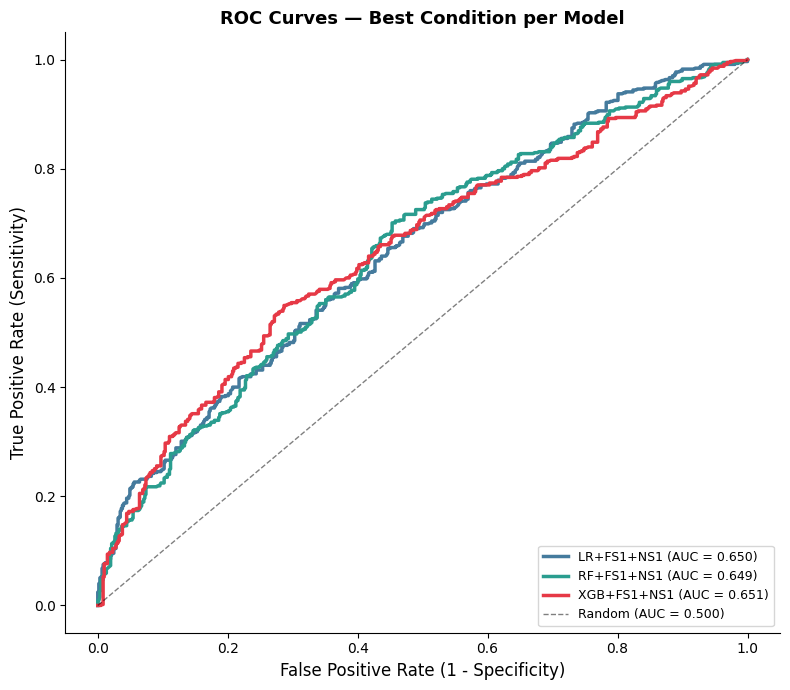

Saved: roc_curves.png


In [37]:
# Best condition per model
best_lr  = max(lr_results,  key=lambda r: r['Mean AUC'])
best_rf  = max(rf_results,  key=lambda r: r['Mean AUC'])
best_xgb = max(xgb_results, key=lambda r: r['Mean AUC'])

fig, ax = plt.subplots(figsize=(8, 7))

colours = {'LR': '#457B9D', 'RF': '#2A9D8F', 'XGB': '#E63946'}

for r in [best_lr, best_rf, best_xgb]:
    fpr, tpr, _ = roc_curve(r['y_true'], r['y_proba'])
    label = (f"{r['Model']}+{r['Feature Set']}+{r['Norm']} "
             f"(AUC = {r['Overall AUC']:.3f})")
    ax.plot(fpr, tpr, label=label, color=colours[r['Model']], linewidth=2.5)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('ROC Curves — Best Condition per Model', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_curves.png')

##  Per-Fold AUC Heatmap

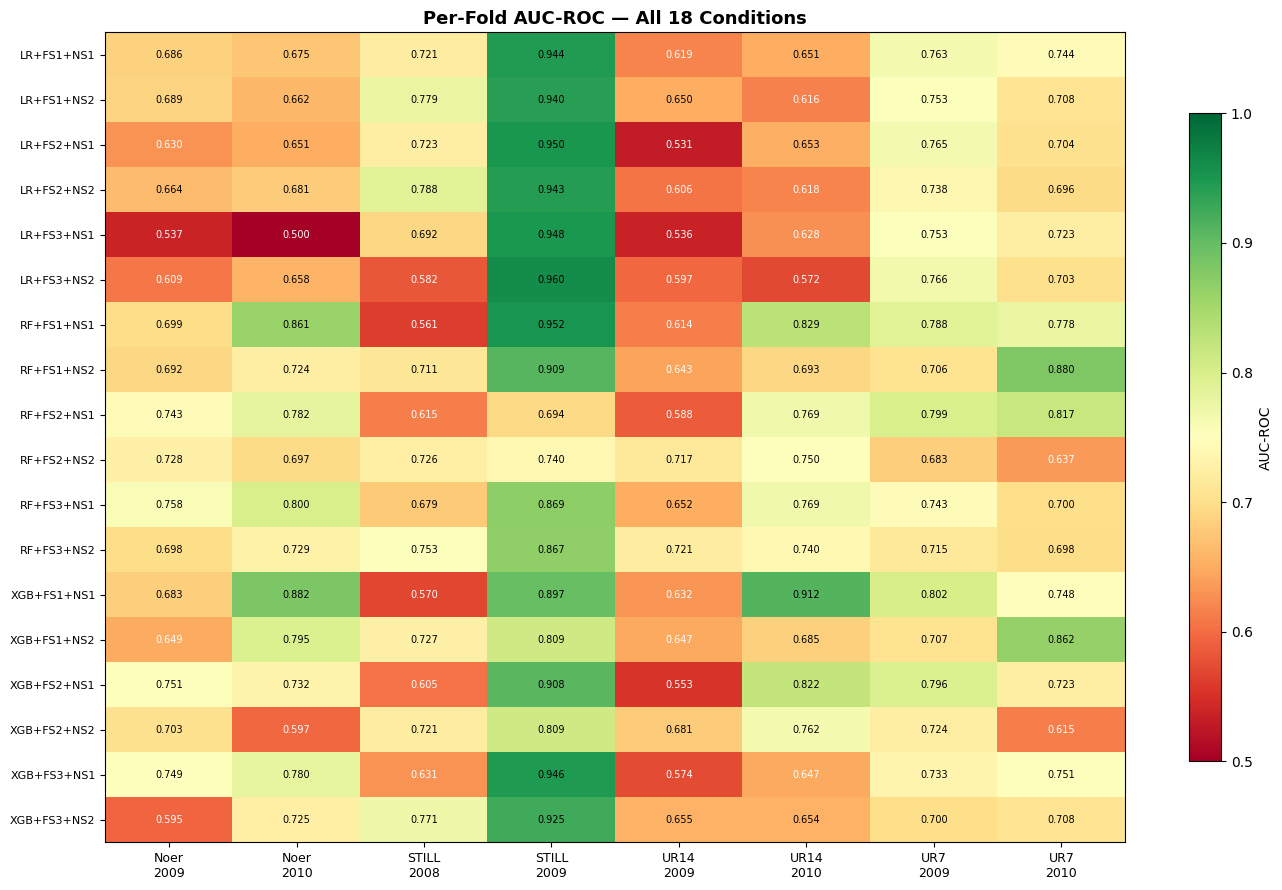

Saved: fold_auc_heatmap.png


In [65]:
conds  = [f"{r['Model']}+{r['Feature Set']}+{r['Norm']}" for r in all_results]
matrix = np.array([
    [r['fold_results'].get(sy, float('nan')) for sy in sy_list]
    for r in all_results
])

fig, ax = plt.subplots(figsize=(14, 9))
im = ax.imshow(matrix, cmap='RdYlGn', vmin=0.5, vmax=1.0, aspect='auto')
plt.colorbar(im, ax=ax, label='AUC-ROC', shrink=0.8)

ax.set_xticks(range(len(sy_list)))
ax.set_xticklabels([s.replace('_', '\n') for s in sy_list], fontsize=9)
ax.set_yticks(range(len(conds)))
ax.set_yticklabels(conds, fontsize=8)
ax.set_title('Per-Fold AUC-ROC — All 18 Conditions', fontsize=13, fontweight='bold')

for i in range(len(conds)):
    for j in range(len(sy_list)):
        v = matrix[i, j]
        if not np.isnan(v):
            colour = 'white' if v < 0.65 else 'black'
            ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                    fontsize=7, color=colour)

plt.tight_layout()
plt.savefig('fold_auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fold_auc_heatmap.png')

## Normalisation Comparison Bar Chart

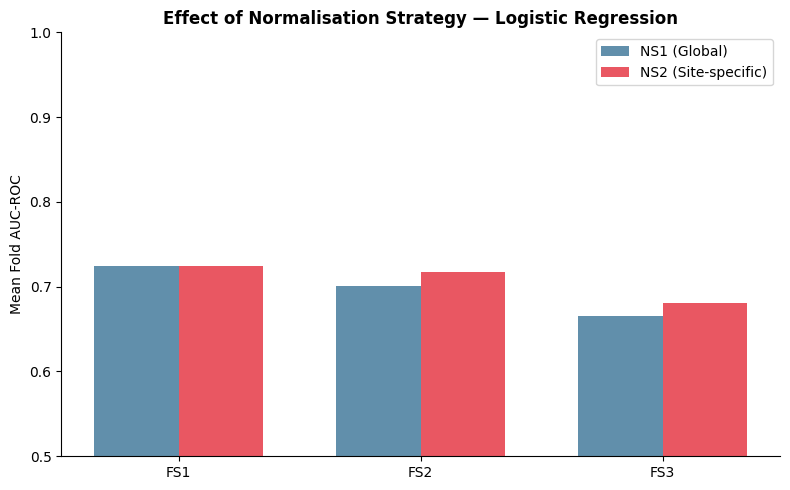

Saved: normalisation_comparison.png


In [38]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(table_55))
w = 0.35

ax.bar(x - w/2, table_55['NS1 Mean AUC'], w,
       label='NS1 (Global)', color='#457B9D', alpha=0.85)
ax.bar(x + w/2, table_55['NS2 Mean AUC'], w,
       label='NS2 (Site-specific)', color='#E63946', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(table_55['Feature Set'])
ax.set_ylabel('Mean Fold AUC-ROC')
ax.set_title('Effect of Normalisation Strategy — Logistic Regression',
             fontweight='bold')
ax.legend()
ax.set_ylim(0.5, 1.0)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('normalisation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: normalisation_comparison.png')

##  Final Summary

In [39]:


print('\nTop 5 conditions by Mean AUC:')
display(table_51.sort_values('Mean AUC', ascending=False).head(5))

baseline = table_51[
    (table_51['Model'] == 'LR') &
    (table_51['Feature Set'] == 'FS1') &
    (table_51['Norm'] == 'NS1')
]
b = baseline['Mean AUC'].values[0]
print(f'\nBaseline LR+FS1+NS1  Mean AUC : {b:.3f}')
print(f'Smith-Kerns benchmark         : 0.770')
print(f'Difference                    : {b - 0.770:+.3f}')

print('\nFiles saved:')
for f in ['results_table_51.csv', 'results_table_52.csv',
          'results_table_53.csv', 'results_table_54.csv',
          'results_table_55.csv', 'roc_curves.png',
          'fold_auc_heatmap.png', 'normalisation_comparison.png']:
    print(f'  {f}')


Top 5 conditions by Mean AUC:


,Model,Feature Set,Norm,Mean AUC,SD,Overall AUC,Sens@20%,Spec@20%
12,XGB,FS1,NS1,0.766,0.121,0.651,0.861,0.231
6,RF,FS1,NS1,0.760,0.121,0.649,0.866,0.260
10,RF,FS3,NS1,0.746,0.066,0.645,0.972,0.071
7,RF,FS1,NS2,0.745,0.089,0.683,0.837,0.397
11,RF,FS3,NS2,0.740,0.051,0.694,0.953,0.145



Baseline LR+FS1+NS1  Mean AUC : 0.725
Smith-Kerns benchmark         : 0.770
Difference                    : -0.045

Files saved:
  results_table_51.csv
  results_table_52.csv
  results_table_53.csv
  results_table_54.csv
  results_table_55.csv
  roc_curves.png
  fold_auc_heatmap.png
  normalisation_comparison.png
